Part 1: Initial Instructions (Loading, Exploring, and Handling Data)

In [1]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Instruction 1: Load the Titanic dataset
# We will use Seaborn's built-in titanic dataset for ease of use in Colab
df = sns.load_dataset('titanic')

# Instruction 2: Perform basic data exploration using info() and describe()
print("--- Data Info ---")
df.info()
print("\n--- Data Description ---")
print(df.describe())

# Instruction 3: Handle missing values if necessary
# Checking for missing values
print("\n--- Missing Values Before ---")
print(df.isnull().sum())

# Handling missing values
# 'age' has missing values, we'll fill with the median
df['age'] = df['age'].fillna(df['age'].median())
# 'embarked' and 'embark_town' have a few missing values, fill with the mode
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])
# 'deck' has too many missing values, we will drop the column for this EDA
df = df.drop(columns=['deck'])

print("\n--- Missing Values After ---")
print(df.isnull().sum())

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB

--- Data Description ---
         survived      pclass      

Part 2: Assignment Questions (Visualization Based)

Q1.
Create a countplot to show the number of passengers by gender

/tmp/ipykernel_1146/2830019514.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sex', palette='Set2')


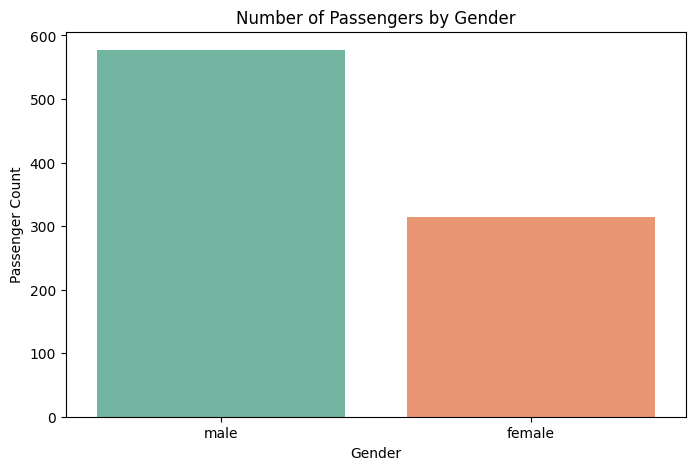

In [2]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='sex', palette='Set2')
plt.title('Number of Passengers by Gender')
plt.xlabel('Gender')
plt.ylabel('Passenger Count')
plt.show()

Interpretation: The countplot indicates that there were significantly more male passengers on the Titanic than female passengers.  

Q2.
Create a bar chart to show the number of passengers in each passenger class using different colors

/tmp/ipykernel_1146/770575342.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='pclass', palette='viridis')


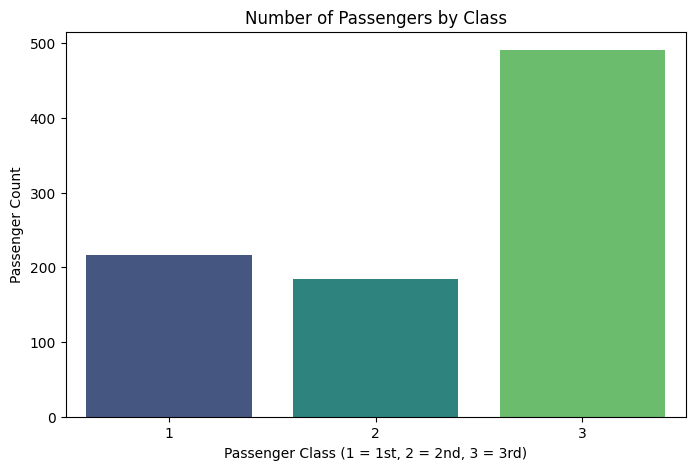

In [3]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='pclass', palette='viridis')
plt.title('Number of Passengers by Class')
plt.xlabel('Passenger Class (1 = 1st, 2 = 2nd, 3 = 3rd)')
plt.ylabel('Passenger Count')
plt.show()

Interpretation: The 3rd class had the highest number of passengers, outnumbering the 1st and 2nd classes combined. The 2nd class had the fewest passengers.  

Q3.
Create a histogram to show the distribution of passenger age

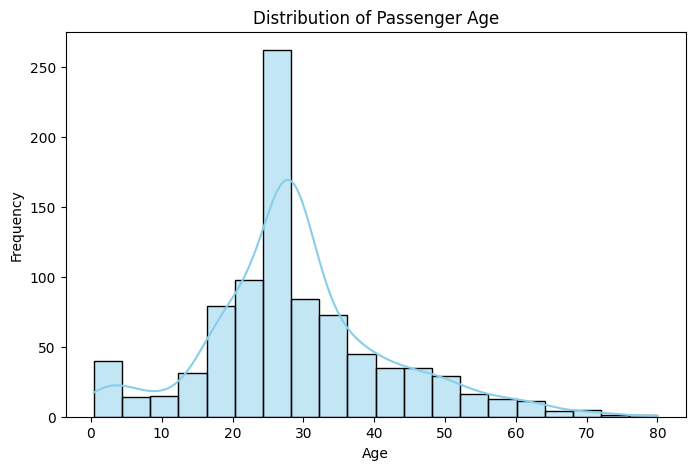

In [4]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='age', bins=20, kde=True, color='skyblue')
plt.title('Distribution of Passenger Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

Interpretation: The age distribution is roughly right-skewed, with the majority of passengers being between 20 and 30 years old. There is also a noticeable spike in infants and young children.  

Q4.
Create a boxplot to detect outliers in the fare column

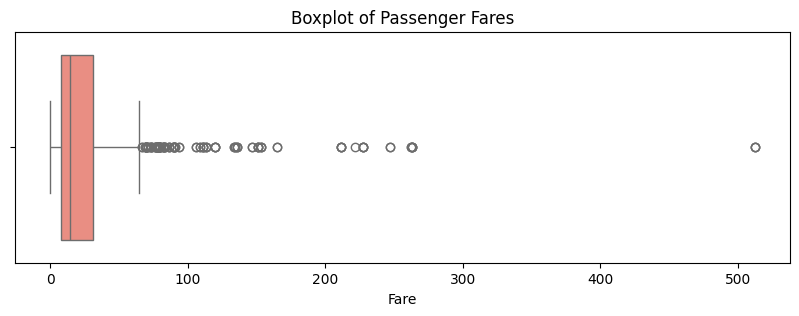

In [5]:
plt.figure(figsize=(10, 3))
sns.boxplot(data=df, x='fare', color='salmon')
plt.title('Boxplot of Passenger Fares')
plt.xlabel('Fare')
plt.show()

Interpretation: The boxplot reveals a high number of outliers above the upper whisker, indicating that a few passengers paid exceptionally high fares (exceeding $100 and up to over $500), while the vast majority paid lower fares.  

Q5.
Create a scatterplot to analyze relationships

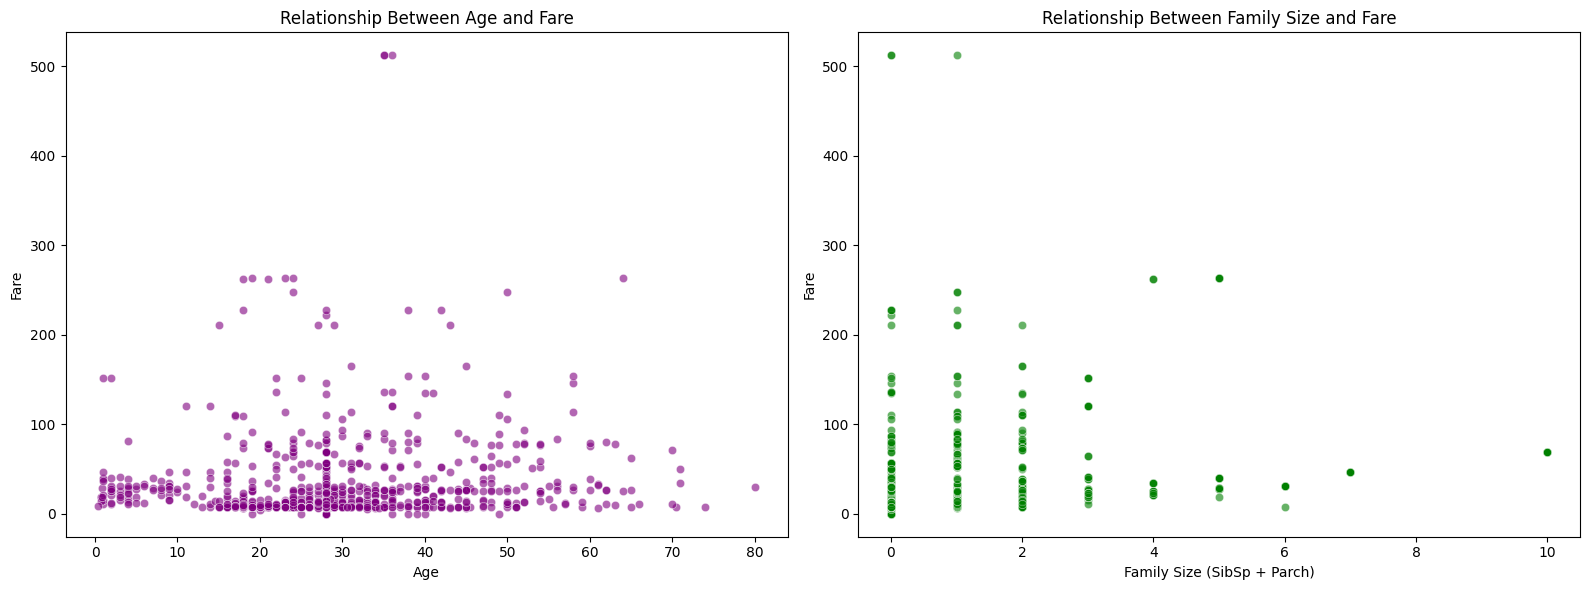

In [6]:
# Create the family size column: SibSp + Parch
df['family_size'] = df['sibsp'] + df['parch']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Q5a. Scatterplot: Age vs Fare
sns.scatterplot(ax=axes[0], data=df, x='age', y='fare', alpha=0.6, color='purple')
axes[0].set_title('Relationship Between Age and Fare')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Fare')

# Q5b. Scatterplot: Family Size vs Fare
sns.scatterplot(ax=axes[1], data=df, x='family_size', y='fare', alpha=0.6, color='green')
axes[1].set_title('Relationship Between Family Size and Fare')
axes[1].set_xlabel('Family Size (SibSp + Parch)')
axes[1].set_ylabel('Fare')

plt.tight_layout()
plt.show()

Interpretation: *
Age vs. Fare:
There is no strong linear relationship between a passenger's age and the fare they paid. High fares are scattered across different ages.  

Family Size vs. Fare:
Passengers traveling alone or with smaller families generally paid lower fares, while the exceptionally high fares are often linked to slightly larger family sizes, though some large families also traveled on cheap tickets.

Q6.
Create a countplot to show survival count by gender

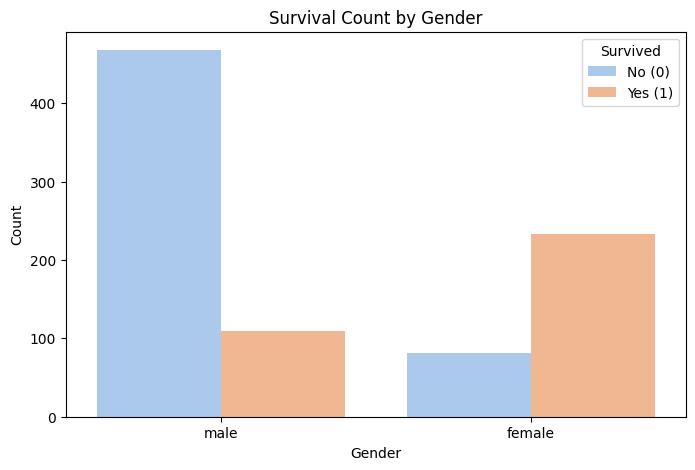

In [7]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='sex', hue='survived', palette='pastel')
plt.title('Survival Count by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['No (0)', 'Yes (1)'])
plt.show()

Interpretation: Females had a significantly higher survival rate than males. Despite there being more male passengers overall, a much larger absolute number of females survived.  

Q7.
Create a bar chart to show survival by passenger class

/tmp/ipykernel_1146/4163685643.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='pclass', y='survived', palette='coolwarm')


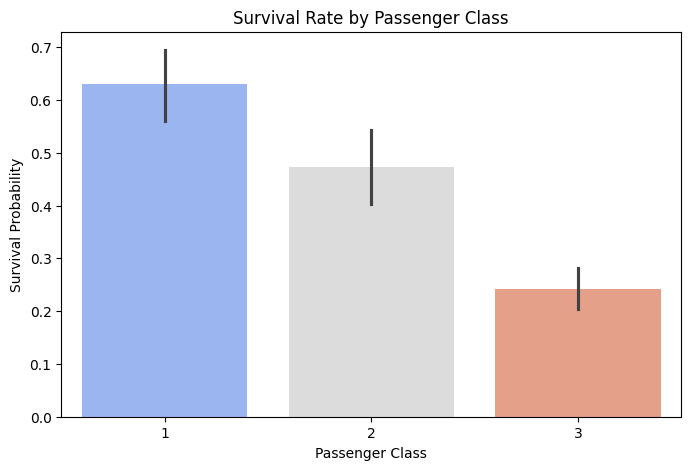

In [8]:
plt.figure(figsize=(8, 5))
# Using a barplot to show the probability/proportion of survival
sns.barplot(data=df, x='pclass', y='survived', palette='coolwarm')
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Probability')
plt.show()

Interpretation: The survival probability directly correlates with passenger class. 1st class passengers had the highest chance of survival, followed by 2nd class, and 3rd class passengers had the lowest survival rate.  

Q8.
Create a heatmap to show correlation between numerical variables

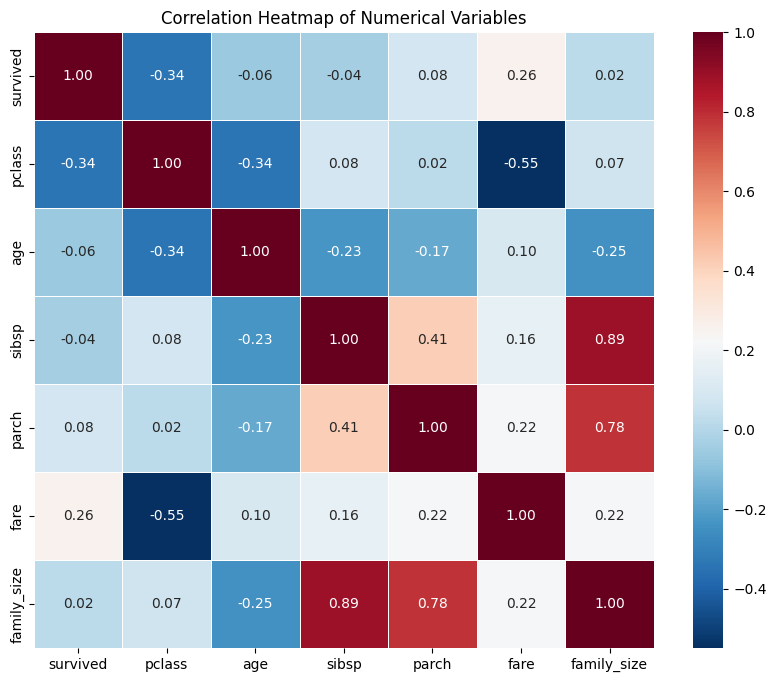

In [9]:
plt.figure(figsize=(10, 8))
# Select only numerical columns for correlation
numerical_df = df.select_dtypes(include=['int64', 'float64'])
correlation_matrix = numerical_df.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

Interpretation: There is a moderate positive correlation between fare and survived, and a strong negative correlation between pclass and fare. sibsp and parch show a moderate positive correlation with each other.  

Q9.
Identify which passenger class paid the highest fare on average

   pclass       fare
0       1  84.154687
1       2  20.662183
2       3  13.675550


/tmp/ipykernel_1146/2905671867.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_fare_by_class, x='pclass', y='fare', palette='magma')


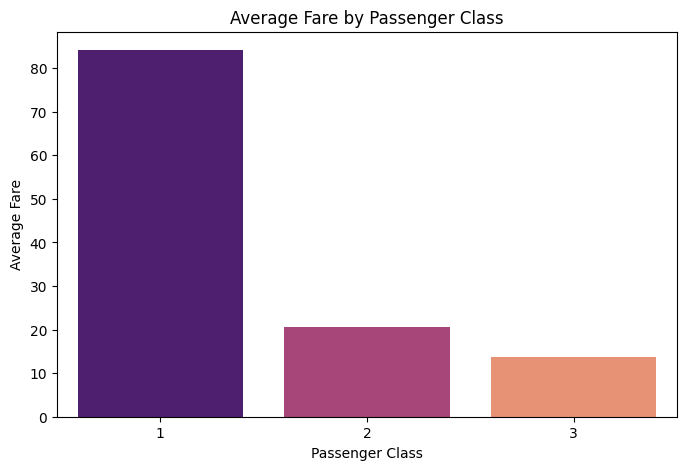

In [10]:
# Calculate the average fare per passenger class
avg_fare_by_class = df.groupby('pclass')['fare'].mean().reset_index()
print(avg_fare_by_class)

# Optional visualization for this insight
plt.figure(figsize=(8, 5))
sns.barplot(data=avg_fare_by_class, x='pclass', y='fare', palette='magma')
plt.title('Average Fare by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Average Fare')
plt.show()

Interpretation: The code output and subsequent chart will clearly show that 1st Class passengers paid the highest fare on average.  

Q10.
Write at least 5 insights from the dataset based on your visualizations

1. Gender Disparity in Survival: The "women and children first" protocol was highly evident. While the majority of passengers aboard were male, female passengers had a drastically higher likelihood of surviving the disaster.

2. Socioeconomic Status Mattered: Passenger class played a critical role in survival outcomes. 1st class passengers were much more likely to survive compared to those in 3rd class, indicating that higher socio-economic status likely afforded better access to lifeboats.

3. Fare Distribution was Highly Skewed: The boxplot analysis revealed that fare prices were not evenly distributed. Most passengers traveled on cheaper 3rd class tickets, while a small minority paid exorbitant amounts for luxury accommodations, creating severe outliers in the data.

4. Age Profile of the Ship: The Titanic was largely populated by young adults in their 20s and 30s. There was not a strong correlation between age and the fare paid, meaning young and old passengers were distributed across all ticket price points.

5. Class and Fare Correlation: As confirmed by both the heatmap and the average fare calculation, there is an inverse relationship between passenger class and fare. 1st class tickets were by far the most expensive on average, which heavily influenced their overall correlation with higher survival rates.